In [1]:
%pip install scikit-learn matplotlib seaborn pandas numpy graphviz

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Graph config
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


In [10]:
import gzip
import os

# dataset_path = path to dataset
dataset_path = './dataset/MNIST/' 

def load_mnist_images(filename):
    filepath = os.path.join(dataset_path, filename)
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    with gzip.open(filepath, 'rb') as f:
        # Skip header (16 bytes for images)
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    # Reshape: (num_images, 28*28 pixels)
    return data.reshape(-1, 784)

def load_mnist_labels(filename):
    filepath = os.path.join(dataset_path, filename)
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    with gzip.open(filepath, 'rb') as f:
        # Skip header (8 bytes for labels)
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

print("Loading local dataset files...")

# 1. Load Original Training Data
feature_train_original = load_mnist_images('train-images-idx3-ubyte.gz')
label_train_original = load_mnist_labels('train-labels-idx1-ubyte.gz')

# 2. Load Provided Test Data
feature_test = load_mnist_images('t10k-images-idx3-ubyte.gz')
label_test = load_mnist_labels('t10k-labels-idx1-ubyte.gz')

# 3. Normalize Data (0-255 -> 0-1)
if feature_train_original is not None and feature_test is not None:
    feature_train_original = feature_train_original / 255.0
    feature_test = feature_test / 255.0
    
    print(" Data loaded successfully!")
    print(f"feature_train_original shape: {feature_train_original.shape}")
    print(f"label_train_original shape: {label_train_original.shape}")
    print(f"feature_test shape: {feature_test.shape}")
    print(f"label_test shape: {label_test.shape}")
else:
    print(" Error: Could not load data. Please check file names and path.")

Loading local dataset files...
Data loaded successfully!
feature_train_original shape: (60000, 784)
label_train_original shape: (60000,)
feature_test shape: (10000, 784)
label_test shape: (10000,)


In [7]:
# 2.1 Preparing the dataset

feature_train, feature_val, label_train, label_val = train_test_split(
    feature_train_original, 
    label_train_original, 
    test_size=0.2,       # 20% for Validation
    shuffle=True,        # shuffle
    stratify=label_train_original, 
    random_state=42
)

print(f"feature_train (80%): {feature_train.shape}")
print(f"feature_val (20%): {feature_val.shape}")

feature_train (80%): (48000, 784)
feature_val (20%): (12000, 784)


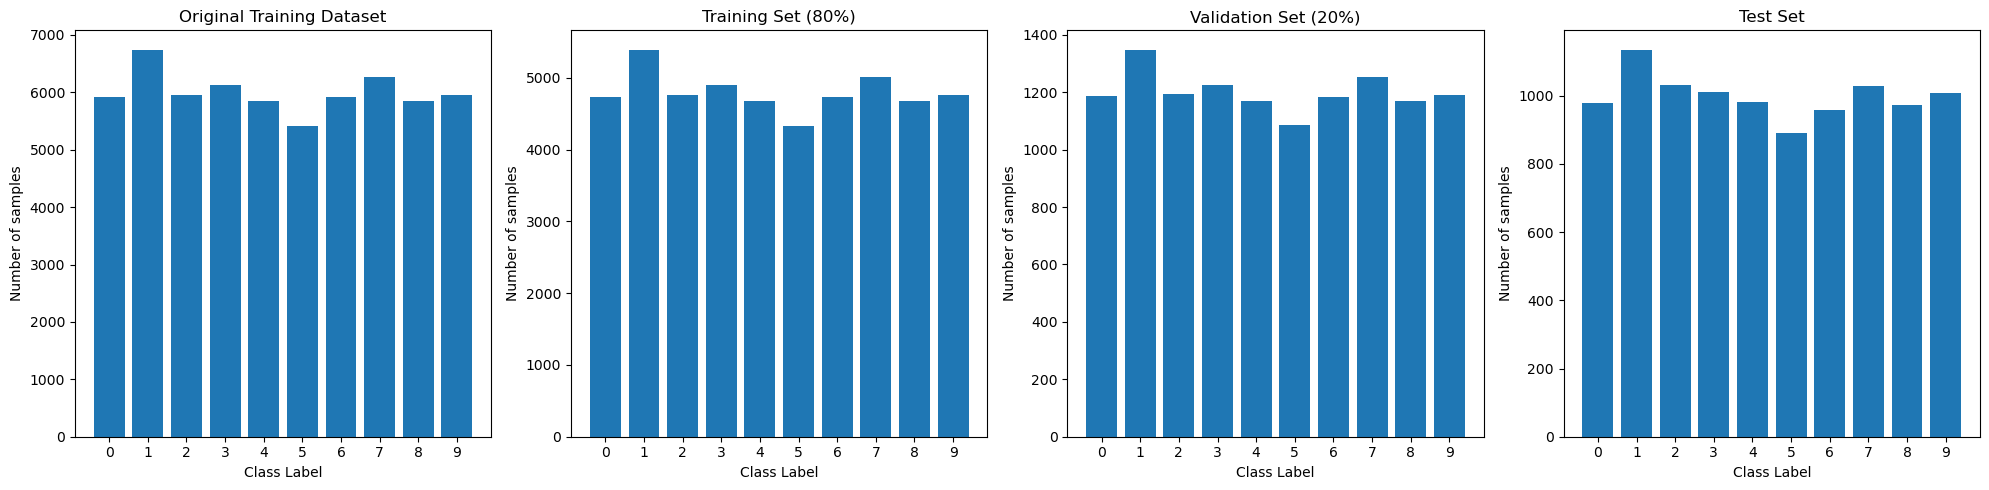

In [9]:
def plot_distribution(labels, title):
    unique, counts = np.unique(labels, return_counts=True)
    plt.bar(unique, counts)
    plt.title(title)
    plt.xlabel('Class Label')
    plt.ylabel('Number of samples')
    plt.xticks(unique)

# Draw the graphs
plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plot_distribution(label_train_original, 'Original Training Dataset')

plt.subplot(1, 4, 2)
plot_distribution(label_train, 'Training Set (80%)')

plt.subplot(1, 4, 3)
plot_distribution(label_val, 'Validation Set (20%)')

plt.subplot(1, 4, 4)
plot_distribution(label_test, 'Test Set')

plt.tight_layout()
plt.show()

In [11]:
# 2.2 Building the decision tree classifier
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)

print("Training Decision Tree (dt_model)...")
dt_model.fit(feature_train, label_train)
print("Training complete.")

Training Decision Tree (dt_model)...
Training complete.


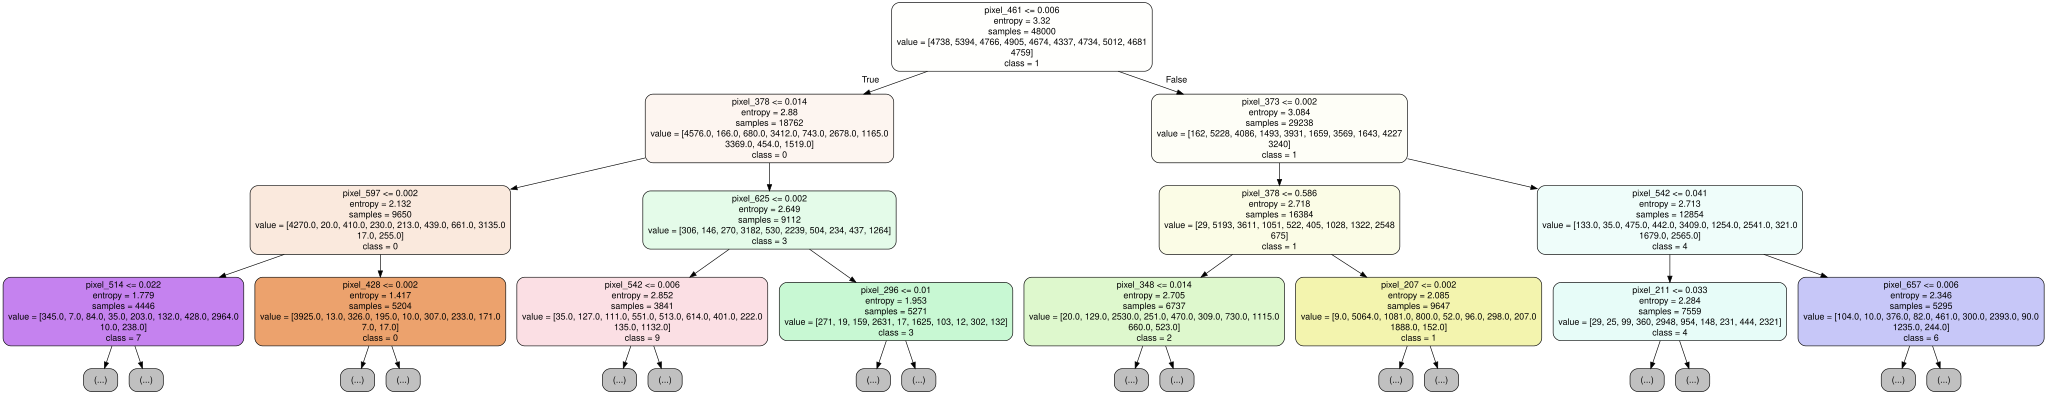

In [13]:
# Export tree data
dot_data = export_graphviz(
    dt_model, 
    out_file=None, 
    max_depth=3,  # Limit depth to read.
    feature_names=[f"pixel_{i}" for i in range(784)],  
    class_names=[str(i) for i in range(10)],  
    filled=True, 
    rounded=True
)

# Render graph as PNG
graph = graphviz.Source(dot_data, format='png') 
graph.render("mnist_tree_viz") 
graph # Display in notebook

In [15]:
# 2.3 Hyperparameter tuning for decision tree classifier
# Define parameters to tune
max_depths = [10, 15, None]
min_samples_splits = [2, 10]
min_samples_leafs = [1, 5]

best_score = 0
best_params = {}
best_dt_model = None

print("Starting hyperparameter tuning...")

for d in max_depths:
    for s in min_samples_splits:
        for l in min_samples_leafs:
            # Train model with current parameters
            clf = DecisionTreeClassifier(
                criterion='entropy', 
                max_depth=d, 
                min_samples_split=s, 
                min_samples_leaf=l, 
                random_state=42
            )
            clf.fit(feature_train, label_train)
            
            # Evaluate on Validation Set
            score = clf.score(feature_val, label_val)
            
            # Keep the best model
            if score > best_score:
                best_score = score
                best_params = {'max_depth': d, 'min_samples_split': s, 'min_samples_leaf': l}
                best_dt_model = clf

print(f"Best Validation Accuracy: {best_score:.4f}")
print(f"Best Hyperparameters: {best_params}")

# Update dt_model to the best found model
dt_model = best_dt_model

Starting hyperparameter tuning...
Best Validation Accuracy: 0.8765
Best Hyperparameters: {'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1}


In [16]:
# 2.4 Building the neural network classifier
# Architecture: 2 Hidden Layers (128, 64), ReLU Activation, Adam Solver
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64), 
    activation='relu', 
    solver='adam', 
    max_iter=50, 
    random_state=42,
    verbose=True # Show training progress
)

print("Training Neural Network (mlp_model)...")
mlp_model.fit(feature_train, label_train)

# validation check
val_acc = mlp_model.score(feature_val, label_val)
print(f"MLP Validation Accuracy: {val_acc:.4f}")

Training Neural Network (mlp_model)...
Iteration 1, loss = 0.43571627
Iteration 2, loss = 0.16846952
Iteration 3, loss = 0.12010066
Iteration 4, loss = 0.09122051
Iteration 5, loss = 0.07330266
Iteration 6, loss = 0.05961026
Iteration 7, loss = 0.04964308
Iteration 8, loss = 0.04071443
Iteration 9, loss = 0.03302461
Iteration 10, loss = 0.02738738
Iteration 11, loss = 0.02263985
Iteration 12, loss = 0.01984247
Iteration 13, loss = 0.01776372
Iteration 14, loss = 0.01521185
Iteration 15, loss = 0.01103859
Iteration 16, loss = 0.01026905
Iteration 17, loss = 0.00906216
Iteration 18, loss = 0.00651439
Iteration 19, loss = 0.00478930
Iteration 20, loss = 0.00331464
Iteration 21, loss = 0.00814571
Iteration 22, loss = 0.00883663
Iteration 23, loss = 0.01320528
Iteration 24, loss = 0.00857522
Iteration 25, loss = 0.00785732
Iteration 26, loss = 0.00432604
Iteration 27, loss = 0.00287112
Iteration 28, loss = 0.00094721
Iteration 29, loss = 0.00072432
Iteration 30, loss = 0.00063139
Iteration 

Predicting on Test Set ...

========== RESULTS: Decision Tree (dt_model) ==========
Accuracy: 0.8830

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       980
           1       0.96      0.97      0.96      1135
           2       0.88      0.87      0.87      1032
           3       0.86      0.87      0.86      1010
           4       0.87      0.87      0.87       982
           5       0.83      0.85      0.84       892
           6       0.90      0.87      0.89       958
           7       0.90      0.90      0.90      1028
           8       0.84      0.84      0.84       974
           9       0.85      0.85      0.85      1009

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



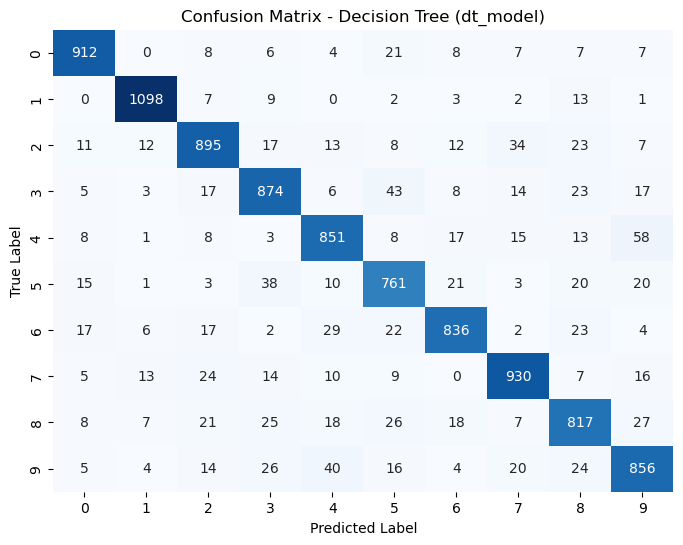


========== RESULTS: Neural Network (mlp_model) ==========
Accuracy: 0.9798

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



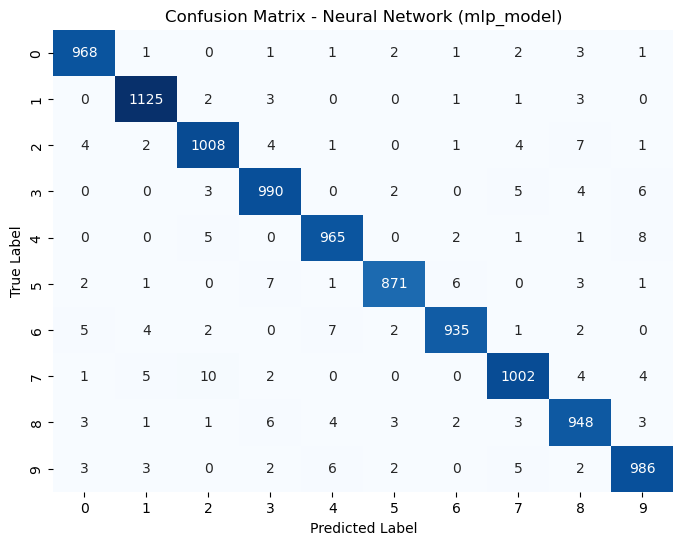

In [18]:
# 2.5 Performance evaluation and comparison
print("Predicting on Test Set ...")

# Predictions
y_pred_dt = dt_model.predict(feature_test)
y_pred_mlp = mlp_model.predict(feature_test)

# Helper function for reporting
def print_evaluation(y_true, y_pred, model_name):
    print(f"\n{'='*10} RESULTS: {model_name} {'='*10}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Display Results
print_evaluation(label_test, y_pred_dt, "Decision Tree (dt_model)")
print_evaluation(label_test, y_pred_mlp, "Neural Network (mlp_model)")